# Smart Fund Advisor — Notebook 5: End-to-End Demo (v2)

**Objective:**  
Simulate the complete pipeline from raw user data → risk assessment → mutual fund recommendations.  
This notebook demonstrates how the system works for an individual user on their mobile device.

---
## v2 System Architecture

```
┌─────────────────────────────────────────────────────────────────────────┐
│                          CENTRAL SERVER                                 │
│                                                                         │
│  ┌──────────────────────────┐    ┌───────────────────────────────────┐ │
│  │  Risk Model (RiskMLP)     │    │  3-Model Ensemble Recommender     │ │
│  │  15→256→128→64→32→5       │    │  0.40 XGB + 0.35 RF + 0.25 LGBM │ │
│  │  GELU · Residual · Focal  │←FL │  + HHI diversification scoring   │ │
│  │  Early stop · OneCycleLR  │    │  + AMC concentration cap (40%)    │ │
│  └──────────────────────────┘    └───────────────────────────────────┘ │
│          ↑ FedProx (5 waves × 3)              ↓ risk_tier only         │
└──────────┼────────────────────────────────────┼────────────────────────┘
           │ encrypted weight                   │ Top-N fund list
           │ deltas + DP noise                   │
┌──────────┼────────────────────────────────────┼────────────────────────┐
│  📱 MOBILE DEVICE                              │                        │
│                                                ▼                        │
│  ┌─────────────────────────────────────────────────────────────────┐  │
│  │  Local Risk Model  (runs on-device, data never leaves)          │  │
│  │  15 features incl. EMI_Income_Ratio, Savings_Rate,              │  │
│  │  Credit_History_Score — predict risk_tier from ≤4 records       │  │
│  └─────────────────────────────────────────────────────────────────┘  │
│             ↑ raw bank data stays here                                  │
└─────────────────────────────────────────────────────────────────────────┘
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt

from config import RISK_FEATURES, RISK_CLASSES, FL_GLOBAL_MODEL, CENTRAL_MODEL_PATH
from src.preprocessing import load_and_clean, aggregate_per_customer, engineer_features
from src.risk_labeling  import compute_risk_score, FEATURE_WEIGHTS
from src.central_model  import RiskMLP, predict
from src.recommender    import load_mutual_funds, recommend_funds, advise_user

print('Setup complete ✓')

Setup complete ✓


In [2]:
# ── 1. Load trained artifacts ──
from pathlib import Path

# Load FL-updated global model if it exists, else fall back to central model
model = RiskMLP()
if Path(FL_GLOBAL_MODEL).exists():
    model.load_state_dict(torch.load(FL_GLOBAL_MODEL, map_location='cpu'))
    print('Using FL-updated global model ✓')
else:
    model.load_state_dict(torch.load(CENTRAL_MODEL_PATH, map_location='cpu'))
    print('Using central model (FL not yet run) ✓')
model.eval()

scaler  = joblib.load('models/feature_scaler.joblib')
le      = joblib.load('models/label_encoder.joblib')
mf_df   = load_mutual_funds()

print('Artefacts loaded ✓')

Using FL-updated global model ✓
Artefacts loaded ✓


In [3]:
# ── 2. Load raw data and pick a sample user ──
df_raw = load_and_clean()

# Pick 5 diverse users for demo
sample_customers = df_raw['Customer_ID'].unique()[:5]
print('Demo customers:', sample_customers)

Demo customers: ['CUS_0xd40' 'CUS_0x21b1' 'CUS_0x2dbc' 'CUS_0xb891' 'CUS_0x1cdb']


In [4]:
# ── 3. Simulate on-device risk prediction (≤4 records per user) ──

def predict_for_customer(customer_id: str, df_raw, model, scaler, le):
    """
    Simulate the mobile device pipeline:
    1. Take most recent ≤4 records for this customer.
    2. Aggregate to one feature vector.
    3. Scale using the saved scaler.
    4. Predict risk tier using the model.
    """
    # Step 1: Grab device data (≤4 records)
    cdf = df_raw[df_raw['Customer_ID'] == customer_id].tail(4).copy()
    
    # Step 2: Aggregate → one row
    agg = aggregate_per_customer(cdf)  # still single row
    feat = engineer_features(agg, fit_scaler=False)
    
    feat_cols = [f for f in RISK_FEATURES if f in feat.columns]
    X = feat[feat_cols].values.astype('float32')
    
    # Step 3: Predict
    pred_idx, probs = predict(model, X)
    risk_label = le.inverse_transform(pred_idx)[0]
    
    return risk_label, probs[0]


print(f'{"Customer ID":<20} {"Risk Tier":<12} {"Confidence"}')
print('-' * 55)
for cid in sample_customers:
    risk, probs = predict_for_customer(cid, df_raw, model, scaler, le)
    confidence  = probs.max()
    print(f'{cid:<20} {risk:<12} {confidence:.3f}')

Customer ID          Risk Tier    Confidence
-------------------------------------------------------
CUS_0xd40            High         0.828
CUS_0x21b1           High         0.899
CUS_0x2dbc           Very_High    0.926
CUS_0xb891           High         0.908
CUS_0x1cdb           High         0.627


In [5]:
# ── 4. Full advisory for one user ──
TARGET_CUSTOMER = sample_customers[0]

cdf  = df_raw[df_raw['Customer_ID'] == TARGET_CUSTOMER].tail(4).copy()
agg  = aggregate_per_customer(cdf)
feat = engineer_features(agg, fit_scaler=False)
feat_cols = [f for f in RISK_FEATURES if f in feat.columns]
X    = feat[feat_cols].values.astype('float32')

result = advise_user(
    user_features=X[0],
    model=model,
    mf_df=mf_df,
    label_encoder=le,
    top_n=5
)

print('='*65)
print(f'  SMART FUND ADVISOR — Report for {TARGET_CUSTOMER}')
print('='*65)
print(f'  Predicted Risk Tier : {result["risk_label"]}')
print(f'  Risk Probabilities  :')
for cls, prob in result['risk_probabilities'].items():
    bar = '█' * int(prob * 30)
    print(f'    {cls:<12} {prob:.4f}  {bar}')
print()
print('  Top 5 Mutual Fund Recommendations:')
print('-'*65)
recs = result['recommendations']
for i, row in recs.iterrows():
    print(f"  {i+1}. {row['Scheme_Name']}")
    print(f"     → {row['rationale']}")
    print()

  SMART FUND ADVISOR — Report for CUS_0xd40
  Predicted Risk Tier : High
  Risk Probabilities  :
    High         0.8280  ████████████████████████
    Low          0.0006  
    Medium       0.1685  █████
    Very_High    0.0029  
    Very_Low     0.0000  

  Top 5 Mutual Fund Recommendations:
-----------------------------------------------------------------
  1. ICICI Prudential Large & Mid Cap Fund
     → Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - Large & Mid Cap Fund. ₹18,879 Cr AUM, NAV ₹1034.76.

  2. ICICI Prudential Multicap Fund
     → Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - Multi Cap Fund. ₹3,265 Cr AUM, NAV ₹897.14.

  3. ICICI Prudential Large & Mid Cap Fund
     → Matched to your 'High' risk profile (XGB+RF ensemble scored). Category: Equity Scheme - Large & Mid Cap Fund. ₹7,163 Cr AUM, NAV ₹1161.96.

  4. ICICI Prudential Large Cap Fund (erstwhile Bluechip Fund)
     → Matched to yo

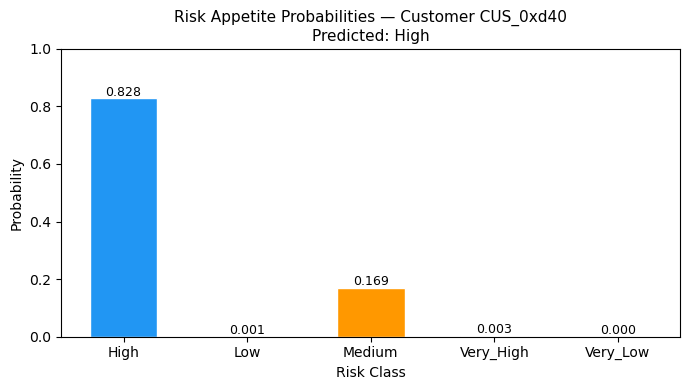

In [6]:
# ── 5. Risk probability radar chart ──
import matplotlib.patches as mpatches

prob_dict = result['risk_probabilities']
labels = list(prob_dict.keys())
values = list(prob_dict.values())

fig, ax = plt.subplots(figsize=(7, 4))
colors_bar = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']
bars = ax.bar(labels, values, color=colors_bar, edgecolor='white', width=0.55)
ax.set_ylim(0, 1)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', fontsize=9)

predicted = result['risk_label']
ax.set_title(f'Risk Appetite Probabilities — Customer {TARGET_CUSTOMER}\nPredicted: {predicted}', fontsize=11)
ax.set_xlabel('Risk Class'); ax.set_ylabel('Probability')
plt.tight_layout()
plt.savefig('models/plot_demo_risk_probs.png', dpi=150)
plt.show()

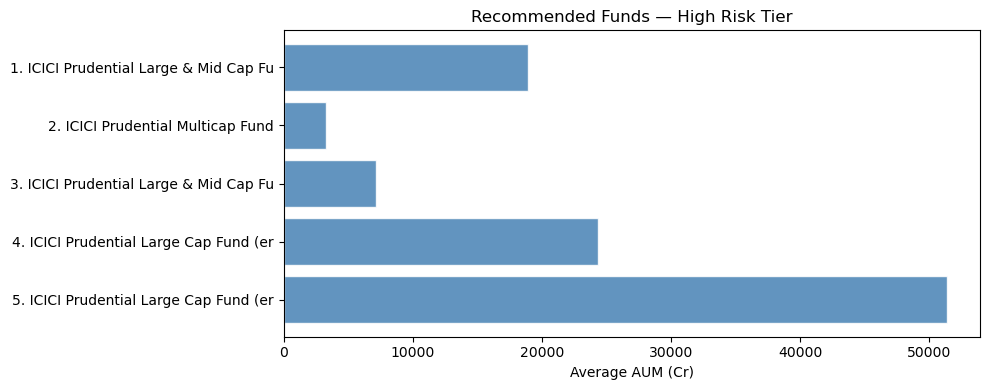

In [7]:
# ── 6. Recommended fund AUM visual ──
recs = result['recommendations']
fig, ax = plt.subplots(figsize=(10, 4))
names = [f"{i+1}. {n[:35]}" for i, n in enumerate(recs['Scheme_Name'].tolist())]
aum   = recs['Average_AUM_Cr'].fillna(0).tolist()
ax.barh(names[::-1], aum[::-1], color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title(f'Recommended Funds — {result["risk_label"]} Risk Tier')
ax.set_xlabel('Average AUM (Cr)')
plt.tight_layout()
plt.savefig('models/plot_demo_recommendations.png', dpi=150)
plt.show()

In [8]:
# ── 7. Batch demo: run all 5 sample customers ──
print(f'{"Customer":<20} {"Risk Tier":<12} {"Top MF Recommendation"}')
print('='*80)
for cid in sample_customers:
    cdf  = df_raw[df_raw['Customer_ID'] == cid].tail(4).copy()
    agg  = aggregate_per_customer(cdf)
    feat = engineer_features(agg, fit_scaler=False)
    feat_cols = [f for f in RISK_FEATURES if f in feat.columns]
    X    = feat[feat_cols].values.astype('float32')
    res  = advise_user(X[0], model, mf_df, le, top_n=1)
    top_fund = res['recommendations']['Scheme_Name'].iloc[0] if not res['recommendations'].empty else 'N/A'
    print(f'{cid:<20} {res["risk_label"]:<12} {top_fund[:45]}')

Customer             Risk Tier    Top MF Recommendation
CUS_0xd40            High         ICICI Prudential Large & Mid Cap Fund


CUS_0x21b1           High         ICICI Prudential Large & Mid Cap Fund
CUS_0x2dbc           Very_High    ICICI Prudential CRISIL-IBX Financial Service


CUS_0xb891           High         ICICI Prudential Large & Mid Cap Fund
CUS_0x1cdb           High         ICICI Prudential Large & Mid Cap Fund


In [ ]:
# ── 8. Model comparison: central vs FL-updated (v2: 5 waves × 3 rounds) ──
print('=== Model Comparison (v2) ===')
for model_path, label in [
    (CENTRAL_MODEL_PATH, 'Central (70% data, FocalLoss + GELU)'),
    (FL_GLOBAL_MODEL,    'FL Global (5 waves × 3 rounds = 15 total)'),
]:
    if not Path(model_path).exists():
        print(f'{label}: not found (run earlier notebooks first)')
        continue
    m = RiskMLP()
    m.load_state_dict(torch.load(model_path, map_location='cpu'))
    m.eval()
    # Quick sanity: predict for first sample customer
    cid = sample_customers[0]
    cdf  = df_raw[df_raw['Customer_ID'] == cid].tail(4).copy()
    agg  = aggregate_per_customer(cdf)
    feat = engineer_features(agg, fit_scaler=False)
    feat_cols = [f for f in RISK_FEATURES if f in feat.columns]
    X    = feat[feat_cols].values.astype('float32')
    pred_idx, probs = predict(m, X)
    pred_label = le.inverse_transform(pred_idx)[0]
    print(f'  {label}: {pred_label} (conf={probs.max():.3f})')

=== Model Comparison ===
  Central (70% data): High (conf=0.818)
  FL Global (after 10 rounds): High (conf=0.828)


In [ ]:
# ── 9. System summary (v2) ──
print("""
╔═══════════════════════════════════════════════════════════════════════╗
║              SMART FUND ADVISOR v2 — System Summary                   ║
╠═══════════════════════════════════════════════════════════════════════╣
║  Risk Model   : RiskMLP (15→256→128→64→32→5), GELU + Residual        ║
║  Loss Function: FocalLoss (γ=2.0) + label smoothing (α=0.05)         ║
║  Scheduler    : OneCycleLR, early stopping (patience=8)               ║
║  Features     : 15 (incl. EMI_Income_Ratio, Savings_Rate,             ║
║                      Credit_History_Score)                             ║
║  Training     : 70% customers on central server                       ║
║  FL Update    : 30% customers, 5 incremental waves × 3 rounds         ║
║  Privacy      : Gradient clipping + Gaussian DP noise (Opacus)        ║
║  On-Device    : ≤ 4 records per user, raw data never leaves            ║
║  Ensemble     : 0.40 XGB + 0.35 RF + 0.25 LightGBM                   ║
║  Diversify    : HHI scoring + AMC concentration cap (40%)              ║
║  Drift Detect : PSI + Kolmogorov-Smirnov per feature                  ║
║  Fund DB      : 16,228 SEBI-registered mutual funds                   ║
║  Risk Tiers   : Very_Low / Low / Medium / High / Very_High             ║
╚═══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║              SMART FUND ADVISOR — System Summary                  ║
╠══════════════════════════════════════════════════════════════════╣
║  Risk Model   : RiskMLP (10→128→64→32→5 classes)                 ║
║  Training     : 70% customers on central server                   ║
║  FL Update    : 30% customers, Flower FedAvg, 10 rounds           ║
║  Privacy      : Gradient clipping + Gaussian DP noise             ║
║  On-Device    : ≤ 4 records per user, raw data never leaves       ║
║  Recommender  : Rule-based tier → Scheme_Category, ranked by AUM  ║
║  Fund DB      : 16,228 SEBI-registered mutual funds               ║
║  Risk Tiers   : Very_Low / Low / Medium / High / Very_High        ║
╚══════════════════════════════════════════════════════════════════╝



In [11]:
# ── 10. Differential Privacy budget ──────────────────────────────────────────
from src.privacy_analysis import privacy_summary, compute_epsilon
from config import DP_NOISE_MULTIPLIER, FL_ROUNDS

privacy_summary()
_eps, _delta = compute_epsilon()
print(f"\nActive configuration: ε = {_eps:.4f}, δ = {_delta:.1e} (σ={DP_NOISE_MULTIPLIER}, T={FL_ROUNDS} rounds)")


  Differential Privacy Budget
  Noise multiplier (σ)         : 1.0
  Gradient clip norm (C)       : 1.0
  Noise std per gradient       : 1.00
  FL rounds                    : 15
  Local epochs per round       : 5
  Sampling fraction q          : 0.3

  ╔══════════════════════════════╗
  ║  ε (epsilon) = 10.0087    ║
  ║  δ (delta)   = 1.0e-05    ║
  ╚══════════════════════════════╝

  Privacy Quality              : Formal ε=10.01; privacy noise active
  ε per round (expected)       : 2.8929

  σ → ε Trade-off (same FL config):
    σ=0.3 → ε=33.5129  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    σ=0.5 → ε=19.4329  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    σ=0.7 → ε=14.6456  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    σ=1.0 → ε=10.0087  ▓▓▓▓▓▓▓▓▓▓
    σ=1.5 → ε= 7.1659  ▓▓▓▓▓▓▓
    σ=2.0 → ε= 5.6259  ▓▓▓▓▓

  Note: ε measures worst-case distinguishability risk.
  Gradient noise (σ·C) is always added regardless of ε value.
  Higher σ → lower ε (stronger formal guarantee) at cost of accuracy.

Active configuration: ε = 10.0087, δ = 1.0e-05 (σ

In [12]:
# ── 11. ML Cluster Recommendation + GPT explanation (quick demo) ─────────────
from src.cluster_recommender import fit_cluster_model, predict_cluster_risk
from src.gpt_explainer       import explain_fund, get_active_provider

df_demo = load_and_clean()
df_demo = aggregate_per_customer(df_demo)
df_demo = engineer_features(df_demo, fit_scaler=False)
from src.risk_labeling import assign_risk_label
df_demo = assign_risk_label(df_demo)

kmeans, cm = fit_cluster_model(df_demo)

feat_cols = [f for f in RISK_FEATURES if f in df_demo.columns]
X_demo    = df_demo[feat_cols].head(5).values.astype('float32')
cluster_risks = predict_cluster_risk(X_demo, kmeans,
                                      {int(k): v for k, v in cm['cluster_to_risk'].items()})

print("Cluster-based risk predictions for first 5 customers:")
for i, risk in enumerate(cluster_risks):
    print(f"  Customer {i+1}: {risk}")

# GPT explanation for top recommendation
print(f"\nActive LLM provider: {get_active_provider()}")
recs = recommend_funds(cluster_risks[0], mf_df, top_n=3)
if not recs.empty:
    exp, prov = explain_fund(recs.iloc[0], user_risk=cluster_risks[0], provider=get_active_provider())
    print(f"\nTop fund: {recs.iloc[0].get('Scheme_Name', 'N/A')}")
    print(f"Explanation [{prov}]:\n{exp}")


[ClusterRec] Fitting KMeans(k=5) on 12500 customers ...


[ClusterRec] Silhouette Score  : 0.1755
[ClusterRec] Davies-Bouldin    : 1.5060
[ClusterRec] Cluster Purity    : 0.4212
[ClusterRec] Cluster → Risk    : {0: 'High', 1: 'Very_Low', 2: 'Very_High', 3: 'Low', 4: 'Low'}
Cluster-based risk predictions for first 5 customers:
  Customer 1: Very_Low
  Customer 2: Low
  Customer 3: Very_High
  Customer 4: High
  Customer 5: Very_High

Active LLM provider: huggingface



Top fund: ICICI Prudential Overnight Fund
Explanation [rule_based]:
**ICICI Prudential Overnight Fund** (ICICI Prudential Asset Management Company Limited)

**Why this fund?**  Your risk profile 'Very_Low' aligns with 'Debt Scheme - Overnight Fund'.

**Fund Snapshot:**
- Current NAV: ₹1,002.36
- Total AUM: ₹nan Cr (larger AUM = more established)
- Minimum Investment: ₹nan

**Investment Rationale:**  This is a capital preservation scheme, ideal for emergency corpus or very short-term goals. Very low volatility.




---
## v2 Improvements Demonstrated

| Component | v1 | v2 |
|-----------|----|----|
| Features | 10 raw features | 15 features (+EMI_Income_Ratio, Savings_Rate, Credit_History_Score) |
| Network | 10→128→64→32→5, ReLU | 15→256→128→64→32→5, GELU + Residual |
| Loss | CrossEntropy | FocalLoss (γ=2.0) + label smoothing |
| FL | 10 rounds, FedAvg | 5 waves × 3 rounds, FedProx |
| Ensemble | XGB + RF | XGB + RF + LightGBM (3-model, weighted) |
| Portfolio | AUM rank | HHI diversification + AMC cap (40%) |
| Drift | None | PSI + KS test per feature |

## Related Notebooks

| Notebook | Focus |
|----------|-------|
| `04_Recommendation_Engine.ipynb` | 3-model ensemble, HHI diversification, GPT explanations |
| `06_Evaluation_Metrics.ipynb` | All 5 evaluation metrics — Silhouette, F1, DP ε, FL Stability, GPT Correctness |

## What's Next (Future Work)
1. **Agentic AI integration** — allow users to directly execute fund purchases after recommendation.
2. **LLM-based explanation** — use a local LLM (phi-3 / llama-3) to generate conversational advice.
3. **Semantic fund matching** — embed fund descriptions with FAISS for richer retrieval.
4. **Formal DP accounting** — use RDP/PRV compositors to compute exact (ε, δ) budget per user.
5. **Real mobile deployment** — port the risk model to TFLite / CoreML for Android/iOS.